# Faz 1: İleri Seviye Keşifsel Veri Analizi (EDA)

Bu notebook, güneş enerjisi verilerini derinlemesine incelemek için kullanılacaktır. Odaklanacağımız konular:

1.  **Zaman Serisi Ayrıştırması:** Enerji üretim sinyalini trend, mevsimsellik ve artık (residual) bileşenlerine ayırma.
2.  **İnteraktif Görselleştirmeler:** Veriyi daha iyi keşfetmek için Plotly kullanarak interaktif grafikler oluşturma.
3.  **Zamansal Desenler:** Farklı zaman ölçeklerindeki (günlük, haftalık) desenleri analiz etme.

In [25]:
%pip install plotly statsmodels nbformat


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from src.data_loader import load_data

# Santrallerden biri için veriyi yükleyelim
df = load_data('data1.csv', 1)


Loading data from: data1.csv

                tsi           dni           ghi          temp           atm  \
count  60168.000000  60168.000000  60168.000000  60168.000000  60168.000000   
mean     209.531246     63.196799     52.315300     11.306507    913.978394   
std      329.662614    149.818706     82.034163     14.110502      8.783056   
min        0.000000      0.000000      0.000000    -18.200000    894.900000   
25%        0.000000      0.000000      0.000000     -2.000000    906.200000   
50%        0.000000      1.000000      0.000000     12.300000    914.000000   
75%      340.000000     14.000000     84.000000     23.800000    920.900000   
max     1328.000000    695.000000    401.000000     41.200000    936.300000   

                 rh         power       Day sin       Day cos      Year sin  \
count  60168.000000  60168.000000  60168.000000  60168.000000  6.016800e+04   
mean      23.833699      0.152967      0.532854      0.529994  4.970327e-01   
std       18.348487 

## 1. Zaman Serisi Ayrıştırması (Time-Series Decomposition)

Zaman serisinin altında yatan bileşenleri anlamak için onu ayrıştıralım. Mevsimsel dalgalanmalar zaman serisinin seviyesiyle (örneğin yaz aylarında daha yüksek zirveler) ölçekleniyor gibi göründüğü için çarpımsal bir model (`multiplicative`) kullanacağız.

Non-positive daily values (<=0): 3. Attempting decomposition...
Number of daily observations: 725
Yearly decomposition failed or skipped: Not enough observations for yearly decomposition
Trying additive seasonal_decompose with weekly period=7...


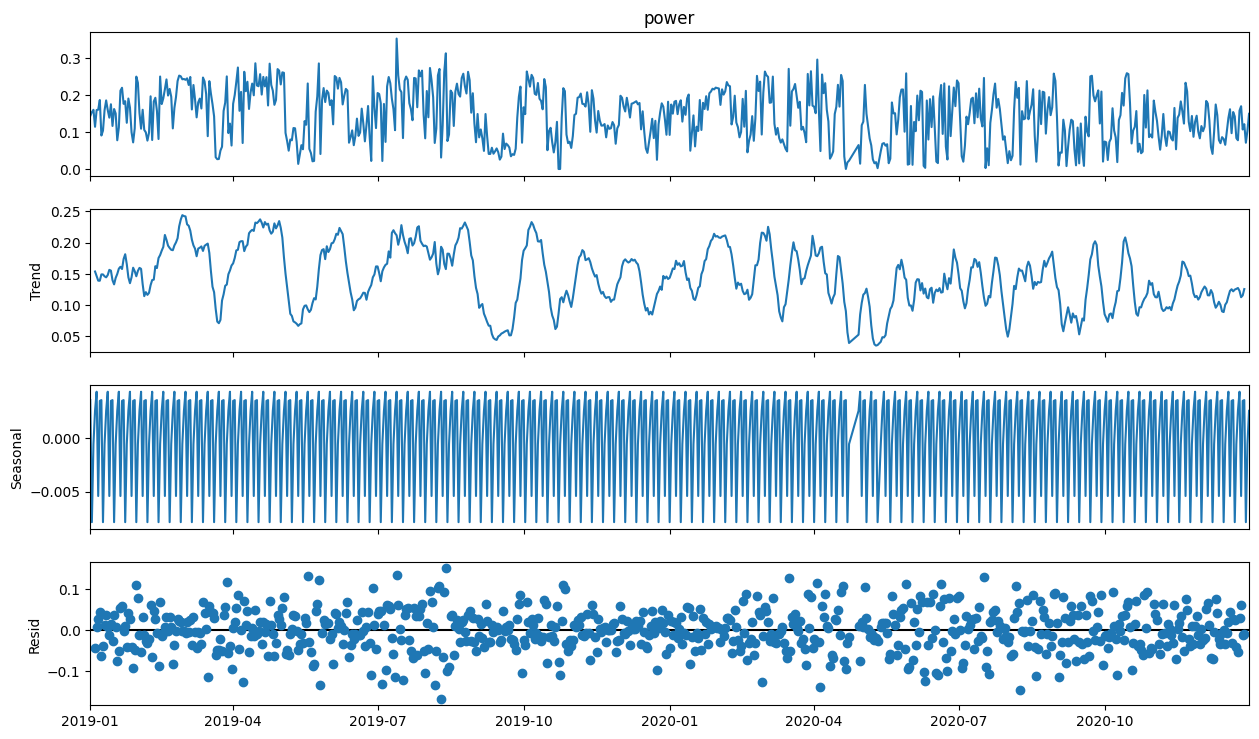

In [27]:
# Trend ve mevsimselliği daha net görebilmek için veriyi günlük ortalamaya göre yeniden örnekleyelim
df_daily = df['power'].resample('D').mean()

# Mevsimsel ayrıştırma yapalım
# Öncelikli hedef: yıllık mevsimsellik (period=365).
# Ancak seasonal_decompose 2*period kontrolü nedeniyle veri uzunluğu yetersizse
# aşağıdaki stratejiyi uyguluyoruz: yıllık -> haftalık -> STL fallback.
num_nonpositive = (df_daily <= 0).sum()
print(f"Non-positive daily values (<=0): {num_nonpositive}. Attempting decomposition...")

series = df_daily.dropna()
n = series.shape[0]
print(f"Number of daily observations: {n}")

decomposition = None
from statsmodels.tsa.seasonal import STL

# Helper to plot a decomposition-like result when we use STL fallback
def _plot_stl_result(series, res):
    fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
    axes[0].plot(series.index, series.values)
    axes[0].set_title('Observed')
    axes[1].plot(res.trend.index, res.trend.values)
    axes[1].set_title('Trend')
    axes[2].plot(res.seasonal.index, res.seasonal.values)
    axes[2].set_title('Seasonal')
    axes[3].plot(res.resid.index, res.resid.values)
    axes[3].set_title('Residual')
    plt.tight_layout()
    plt.show()

# Try yearly decomposition if at least two full years of daily data are available
try:
    if n >= 2 * 365:
        print('Trying additive seasonal_decompose with yearly period=365...')
        decomposition = seasonal_decompose(series, model='additive', period=365)
    else:
        raise ValueError('Not enough observations for yearly decomposition')
except Exception as e_year:
    print('Yearly decomposition failed or skipped:', e_year)
    # Try weekly decomposition (detect weekly patterns)
    try:
        if n >= 2 * 7:
            print('Trying additive seasonal_decompose with weekly period=7...')
            decomposition = seasonal_decompose(series, model='additive', period=7)
        else:
            raise ValueError('Not enough observations for weekly decomposition')
    except Exception as e_week:
        print('Weekly decomposition failed or skipped:', e_week)
        # Fallback to STL which is more flexible for lengths and robust decomposition
        # Choose a sensible seasonal period: prefer yearly if we have at least 365 points, else weekly
        per = 365 if n >= 365 else max(7, n // 10)
        print(f"Falling back to STL with period={per} (robust decomposition)")
        stl_res = STL(series, period=per, robust=True).fit()
        _plot_stl_result(series, stl_res)

# If we obtained a seasonal_decompose result, use its plot method
if decomposition is not None:
    fig = decomposition.plot()
    fig.set_size_inches(14, 8)
    plt.show()
else:
    print('Decomposition finished using STL fallback (plotted above).')

## 2. İnteraktif Zaman Serisi Grafiği

Şimdi, Plotly kullanarak enerji üretim verilerinin interaktif bir grafiğini oluşturalım. Bu, belirli dönemlere yakınlaşmamızı ve veriyi daha iyi anlamamızı sağlayacaktır.

In [28]:
fig = px.line(df, y='power', title='Güneş Enerjisi Üretimi (Santral 1)')
fig.update_xaxes(rangeslider_visible=True)
fig.show()

## 3. Zamansal Isı Haritası (Temporal Heatmap)

Bir zamansal ısı haritası, günün saati ve haftanın günü gibi zaman içinde tekrar eden desenleri görselleştirmek için mükemmeldir. Haftanın her günü ve günün her saati için ortalama enerji üretimini gösteren bir ısı haritası oluşturacağız.

In [29]:
df_heatmap = df.copy()
df_heatmap['hour'] = df_heatmap.index.hour
df_heatmap['day_of_week'] = df_heatmap.index.day_name()

# Bir pivot tablo oluşturalım
pivot = pd.pivot_table(
    df_heatmap, 
    values='power', 
    index='hour', 
    columns='day_of_week', 
    aggfunc='mean'
)

# Haftanın günlerini sıralayalım
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot[days]

# Isı haritasını çizdirelim
fig = px.imshow(
    pivot,
    labels=dict(x="Haftanın Günü", y="Günün Saati", color="Ortalama Güç"),
    x=pivot.columns,
    y=pivot.index,
    title='Saat ve Haftanın Gününe Göre Ortalama Güç Üretimi'
)
fig.update_xaxes(side="top")
fig.show()

In [30]:
# --- Tüm veri setlerini yükleyip özetleyelim (src.data_loader üzerinden) ---
import pandas as pd
from src.data_loader import load_all_data

# Tüm istasyonları yükle (normalize edilmiş güç ve metadata dahildir)
dfs = load_all_data()

# Tek bir DataFrame'de birleştir
df_all = pd.concat(dfs.values(), axis=0)
print('Birleşik veri şekli:', df_all.shape)

# İstasyon bazlı hızlı özet
summary_rows = []
for s, dfi in dfs.items():
    summary_rows.append({
        'station': s,
        'n_rows': len(dfi),
        'mean_power_norm': dfi['power'].mean(),
        'min_power_norm': dfi['power'].min(),
        'max_power_norm': dfi['power'].max(),
        'capacity_MW': dfi['capacity'].iloc[0] if 'capacity' in dfi.columns else None
    })

summary_df = pd.DataFrame(summary_rows).set_index('station')
summary_df


Loading data from: data1.csv

                tsi           dni           ghi          temp           atm  \
count  60168.000000  60168.000000  60168.000000  60168.000000  60168.000000   
mean     209.531246     63.196799     52.315300     11.306507    913.978394   
std      329.662614    149.818706     82.034163     14.110502      8.783056   
min        0.000000      0.000000      0.000000    -18.200000    894.900000   
25%        0.000000      0.000000      0.000000     -2.000000    906.200000   
50%        0.000000      1.000000      0.000000     12.300000    914.000000   
75%      340.000000     14.000000     84.000000     23.800000    920.900000   
max     1328.000000    695.000000    401.000000     41.200000    936.300000   

                 rh         power       Day sin       Day cos      Year sin  \
count  60168.000000  60168.000000  60168.000000  60168.000000  6.016800e+04   
mean      23.833699      0.152967      0.532854      0.529994  4.970327e-01   
std       18.348487 

/workspaces/solar-power-forecast/src/data_loader.py:21: DtypeWarning:

Columns (1,2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.



                tsi           dni           ghi          temp           atm  \
count  50912.000000  50912.000000  50912.000000  50912.000000  50912.000000   
mean     206.697262    185.549949    142.605417     18.501145   1011.643886   
std      279.722171    234.172733    203.742934      9.690318      9.898746   
min        0.000000      0.000000      0.000000     -6.500000    990.700000   
25%        0.000000      0.000000      0.000000     10.000000   1002.600000   
50%       60.000000     65.000000     46.000000     19.700000   1011.500000   
75%      336.000000    328.000000    203.000000     26.100000   1019.500000   
max     1109.000000    930.000000    821.000000     39.500000   1039.400000   

                 rh         power       Day sin       Day cos      Year sin  \
count  50912.000000  50912.000000  50912.000000  50912.000000  5.091200e+04   
mean      69.678298      0.168256      0.492562      0.403205  5.003680e-01   
std       16.254682      0.224651      0.354412    

                tsi           dni           ghi          temp           atm  \
count  69225.000000  69225.000000  69225.000000  69225.000000  69225.000000   
mean     242.583444    215.614976     53.028792     20.626635    830.682391   
std      355.819372    338.276443     67.904280      5.744862      4.016424   
min        0.000000      0.000000      0.000000      3.370000    818.000000   
25%        0.000000      0.000000      0.000000     16.570000    827.890000   
50%        0.000000      0.000000      0.000000     20.670000    830.420000   
75%      442.470000    436.200000    104.800000     24.570000    833.300000   
max     1287.670000   1179.800000    262.200000     36.690000    844.520000   

                 rh         power       Day sin       Day cos      Year sin  \
count  69225.000000  69225.000000  69225.000000  69225.000000  6.922500e+04   
mean      53.930672      0.181325      0.499350      0.501432  5.001738e-01   
std       23.888736      0.262102      0.353437    

,n_rows,mean_power_norm,min_power_norm,max_power_norm,capacity_MW
station,,,,,
1,60168,0.152967,0.000000,0.955600,50.00
2,67312,0.142749,0.000000,0.795538,130.00
3,43900,0.152873,-0.002000,0.980667,30.00
4,67665,0.110631,-0.003385,0.760692,130.00
5,50912,0.168256,0.000000,0.873818,110.00
6,69225,0.181325,0.000000,0.892571,35.00
7,64722,0.165550,0.000000,0.962667,30.00
8,68341,0.132584,0.000000,0.792667,0.93


In [31]:
# --- Özellik Mühendisliği fonksiyonlarını src'den kullanarak örnek özellik setleri üretelim (EDA önizleme) ---
import importlib
import src.feature_engineering as fe
fe = importlib.reload(fe)
from src.feature_engineering import create_features_for_station

# dfs sözlüğünün oluşturulduğundan emin olalım
if 'dfs' not in globals():
    raise RuntimeError("Önce tüm istasyonları yüklediğiniz hücreyi çalıştırın (dfs tanımlı değil).")

features_per_station = {}
for s, df_station in dfs.items():
    feats = create_features_for_station(df_station)
    features_per_station[s] = feats
    print(f'Istasyon {s}: özellik boyutu {feats.shape}')

# Örnek: 1. istasyonun ilk satırları
features_per_station[1].head()

Istasyon 1: özellik boyutu (60144, 30)
Istasyon 2: özellik boyutu (67288, 30)
Istasyon 2: özellik boyutu (67288, 30)
Istasyon 3: özellik boyutu (43876, 30)
Istasyon 3: özellik boyutu (43876, 30)
Istasyon 4: özellik boyutu (67641, 30)
Istasyon 4: özellik boyutu (67641, 30)
Istasyon 5: özellik boyutu (50888, 30)
Istasyon 5: özellik boyutu (50888, 30)
Istasyon 6: özellik boyutu (69201, 30)
Istasyon 6: özellik boyutu (69201, 30)
Istasyon 7: özellik boyutu (64698, 30)
Istasyon 7: özellik boyutu (64698, 30)
Istasyon 8: özellik boyutu (68317, 30)
Istasyon 8: özellik boyutu (68317, 30)


,tsi,dni,ghi,temp,atm,rh,power,Day sin,Day cos,Year sin,...,lag_3,lag_4,lag_6,lag_12,lag_24,roll_mean_3,roll_std_3,roll_mean_24,stl_trend_daily,stl_seasonal_daily
time,,,,,,,,,,,,,,,,,,,,,
2019-01-01 06:00:00,0,0,0,-11.5,929.1,44.6,0.0,1.000000,0.500000,0.503161,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166332,0.025794
2019-01-01 06:15:00,0,1,0,-11.7,929.0,45.1,0.0,0.998929,0.467298,0.503251,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166332,0.025794
2019-01-01 06:30:00,0,0,0,-11.6,928.8,45.0,0.0,0.995722,0.434737,0.503340,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166332,0.025794
2019-01-01 06:45:00,0,1,0,-12.2,928.7,45.8,0.0,0.990393,0.402455,0.503430,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166332,0.025794
2019-01-01 07:00:00,0,0,0,-12.7,928.7,47.4,0.0,0.982963,0.370590,0.503519,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166332,0.025794


## 4. Tüm Veri Setleri için EDA
Bu bölümde her istasyon için kısa özetler ve örnek görseller üretiyoruz.

In [32]:
# Her istasyon için hızlı EDA: özet ve küçük bir zaman serisi grafiği
import plotly.express as px

# Özet tabloyu göster
summary_df

# İstasyon bazında örnek grafikler (ilk 7 gün)
for s, dfi in dfs.items():
    dfi_sample = dfi.iloc[:96*7] if len(dfi) >= 96*7 else dfi.copy()
    fig = px.line(dfi_sample.reset_index(), x='time', y='power', title=f'Istasyon {s} – İlk 7 Gün Normalize Güç')
    fig.update_xaxes(rangeslider_visible=True)
    fig.show()